# Part 2.2 Correlation Analysis

             timestamp  age  gender         country state self_employed  \
0  2014-08-27 11:29:31   37  Female   United States    IL            No   
1  2014-08-27 11:29:37   44    Male   United States    IN            No   
2  2014-08-27 11:29:44   32    Male          Canada    CA            No   
3  2014-08-27 11:29:46   31    Male  United Kingdom    CA            No   
4  2014-08-27 11:30:22   31    Male   United States    TX            No   

  family_history treatment work_interfere    no_employees  ...  \
0             No       Yes          Often            6-25  ...   
1             No        No         Rarely  More than 1000  ...   
2             No        No         Rarely            6-25  ...   
3            Yes       Yes          Often          26-100  ...   
4             No        No          Never         100-500  ...   

  phys_health_consequence coworkers  supervisor  mental_health_interview  \
0                       0       NaN         2.0                       No   


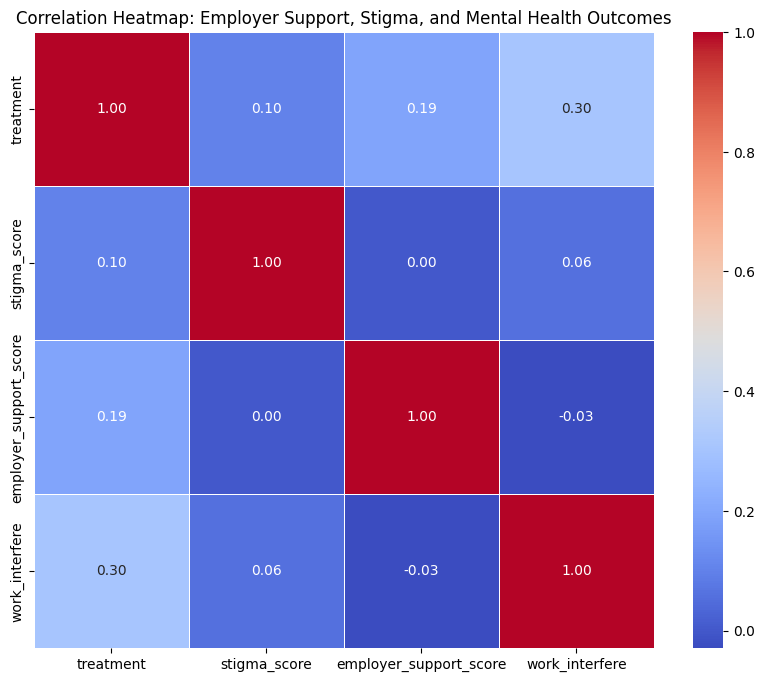

In [1]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the preprocessed dataset
file_path = '/Users/luischan/Downloads/preprocessed_survey.csv'
df = pd.read_csv(file_path)

# Display the first few rows to confirm loading
print(df.head())

# Select relevant columns for correlation analysis
correlation_columns = [
    'treatment',                # Mental health treatment (Yes/No)
    'stigma_score',             # Aggregated stigma score
    'employer_support_score',   # Aggregated employer support score
    'work_interfere'            # How mental health issues interfere with work
]

# Convert 'treatment' to a binary numeric value for correlation (Yes = 1, No = 0)
df['treatment'] = df['treatment'].map({'Yes': 1, 'No': 0})

# Convert 'work_interfere' responses to numeric values
work_interfere_mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Often': 3
}
df['work_interfere'] = df['work_interfere'].map(work_interfere_mapping)

# Calculate the correlation matrix
correlation_matrix = df[correlation_columns].corr()

# Display the correlation matrix
print(correlation_matrix)

# Plot the correlation heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Employer Support, Stigma, and Mental Health Outcomes')
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Compute the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the correlation matrix as a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")

# Save the plot as an image
plt.savefig("static/correlation_matrix.png", bbox_inches='tight')
plt.close()


# **Conclusion: Correlation Analysis**

---

## **Steps Taken**

1. **Data Preparation**:
   - Selected relevant columns: `treatment`, `stigma_score`, `employer_support_score`, and `work_interfere`.
   - Converted categorical data (`treatment` and `work_interfere`) to numeric values for correlation analysis.

2. **Correlation Matrix**:
   - Calculated the correlation matrix to explore relationships between employer support, stigma, work interference, and likelihood of seeking treatment.

3. **Visualization**:
   - Plotted a correlation heatmap for an intuitive understanding of the relationships.

---

## **Results**

|                         | Treatment | Stigma Score | Employer Support Score | Work Interfere |
|-------------------------|-----------|--------------|------------------------|----------------|
| **Treatment**           | 1.00      | 0.10         | 0.19                   | 0.30           |
| **Stigma Score**        | 0.10      | 1.00         | 0.00                   | 0.06           |
| **Employer Support Score** | 0.19   | 0.00         | 1.00                   | -0.03          |
| **Work Interfere**      | 0.30      | 0.06         | -0.03                  | 1.00           |

---

## **Key Findings**

1. **Treatment and Work Interference**:
   - **Correlation**: `0.30`  
   - Individuals experiencing more work interference due to mental health issues are more likely to seek treatment.

2. **Treatment and Employer Support**:
   - **Correlation**: `0.19`  
   - Higher employer support is associated with a greater likelihood of seeking treatment.

3. **Treatment and Stigma Score**:
   - **Correlation**: `0.10`  
   - Weak positive correlation; stigma may have a minor impact on seeking treatment.

4. **Employer Support and Stigma**:
   - **Correlation**: `0.00`  
   - No relationship between employer support and stigma perceptions.

5. **Employer Support and Work Interference**:
   - **Correlation**: `-0.03`  
   - Negligible correlation; employer support does not strongly influence work interference.

---

## **Meaning**

- **Work Interference** and **Employer Support** play important roles in whether individuals seek mental health treatment.
- **Stigma** has a weaker impact, suggesting that other factors influence treatment decisions.
- **Employer Support Policies** and **Stigma** are largely independent, indicating that improving workplace support may not directly reduce stigma but can still encourage treatment-seeking behavior.